# Pure-Walking Dead Reckoning
Annotation-free walking recording. Goal: verify the PDR trajectory matches the GPS shape.

**Pipeline summary**
- **Steps** — detected from *watch* accelerometer (arm-swing peaks are cleaner than pocket bounce)
- **Heading** — estimated from *phone* horizontal acceleration at each step peak (tilt-corrected via `Gravity.csv`; works regardless of how the phone sits in your pocket)
- **Trajectory** — step length × heading, accumulated from origin
- **Reference** — GPS trace from `Location.csv` (same East/North frame, same origin)


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import butter, filtfilt, find_peaks
from scipy.ndimage import median_filter
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# ── Paths ────────────────────────────────────────────────────────────────────
DIR     = Path('../data/NU/Walking')  # ← adjust to your folder

# ── Parameters ───────────────────────────────────────────────────────────────
FS               = 60.0   # resample target (Hz)
WEINBERG_K       = 0.41   # tune against a measured corridor
MIN_PEAK_HEIGHT  = 1.2    # m/s²  — lower = more sensitive
MIN_PEAK_DIST_S  = 0.30   # seconds — caps cadence at ~3.3 Hz
HEADING_SMOOTH   = 5      # median filter window over per-step headings (steps)


## 2. Load data & fix watch clock

The watch epoch is ~17.6 days behind the phone. We shift every watch DataFrame
so `watch t0 == phone t0` before resampling.


In [2]:
def load_csv(path, name):
    f = path / name
    if not f.exists():
        print(f'  MISSING: {name}')
        return None
    return pd.read_csv(f)

# Phone
p_accel   = load_csv(DIR, 'Accelerometer.csv')       # linear accel (gravity removed)
p_gravity = load_csv(DIR, 'Gravity.csv')             # gravity vector in phone frame
p_total   = load_csv(DIR, 'TotalAcceleration.csv')   # linear + gravity (for step detection fallback)
p_orient  = load_csv(DIR, 'Orientation.csv')         # OS yaw (comparison only)
p_loc     = load_csv(DIR, 'Location.csv')            # GPS

# Watch
w_accel   = load_csv(DIR, 'WatchAccelerometer.csv')  # watch linear accel

# ── Clock fix: shift watch epoch to phone t0 ─────────────────────────────────
phone_t0_ns = int(p_accel['time'].iloc[0])

def fix_clock(df):
    """Realign a watch DataFrame so its t0 matches the phone t0."""
    if df is None:
        return None
    df = df.copy()
    offset = phone_t0_ns - int(df['time'].iloc[0])
    df['time'] = df['time'] + offset
    df['seconds_elapsed'] = (df['time'] - phone_t0_ns) / 1e9
    return df

w_accel = fix_clock(w_accel)

duration = p_accel['seconds_elapsed'].iloc[-1]
print(f'Recording duration : {duration:.1f} s')
print(f'Phone accel rows   : {len(p_accel)}  ({len(p_accel)/duration:.1f} Hz)')
if w_accel is not None:
    print(f'Watch accel rows   : {len(w_accel)}  ({len(w_accel)/w_accel["seconds_elapsed"].iloc[-1]:.1f} Hz)')
print(f'Gravity available  : {p_gravity is not None}')
print(f'GPS fixes          : {len(p_loc) if p_loc is not None else 0}')


Recording duration : 110.7 s
Phone accel rows   : 5953  (53.8 Hz)
Watch accel rows   : 8256  (75.4 Hz)
Gravity available  : True
GPS fixes          : 82


## 3. Resample to 60 Hz

All signals onto a common time grid so step indices line up with heading indices.


In [3]:
def resample_df(df, cols, t_start, t_end, fs):
    """Linear interpolation of selected columns onto a uniform fs grid."""
    t_src = df['seconds_elapsed'].to_numpy()
    t_new = np.arange(t_start, t_end, 1.0/fs)
    out = {'seconds_elapsed': t_new}
    for c in cols:
        out[c] = np.interp(t_new, t_src, df[c].to_numpy())
    return pd.DataFrame(out)

# Overlap window
t0 = p_accel['seconds_elapsed'].iloc[0]
t1 = p_accel['seconds_elapsed'].iloc[-1]
if w_accel is not None:
    t0 = max(t0, w_accel['seconds_elapsed'].iloc[0])
    t1 = min(t1, w_accel['seconds_elapsed'].iloc[-1])

p_accel_r   = resample_df(p_accel,   ['x','y','z'], t0, t1, FS)
p_gravity_r = resample_df(p_gravity, ['x','y','z'], t0, t1, FS) if p_gravity is not None else None
p_total_r   = resample_df(p_total,   ['x','y','z'], t0, t1, FS) if p_total is not None else None
w_accel_r   = resample_df(w_accel,   ['x','y','z'], t0, t1, FS) if w_accel is not None else None

t_grid = p_accel_r['seconds_elapsed'].to_numpy()
print(f'Common grid: {t_grid[0]:.2f} – {t_grid[-1]:.2f} s  ({len(t_grid)} samples @ {FS} Hz)')


Common grid: 0.09 – 109.46 s  (6563 samples @ 60.0 Hz)


## 4. Step detection — watch (primary) + phone (comparison)

Watch arm-swing produces cleaner peaks than pocket bounce: fewer double-peaks,
lower noise floor. We use watch steps for the final trajectory.
Phone steps are shown alongside for comparison.


Watch : 160 steps  |  total distance 103.0 m  |  mean step 0.644 m
Phone : 180 steps  |  total distance 133.0 m  |  mean step 0.739 m


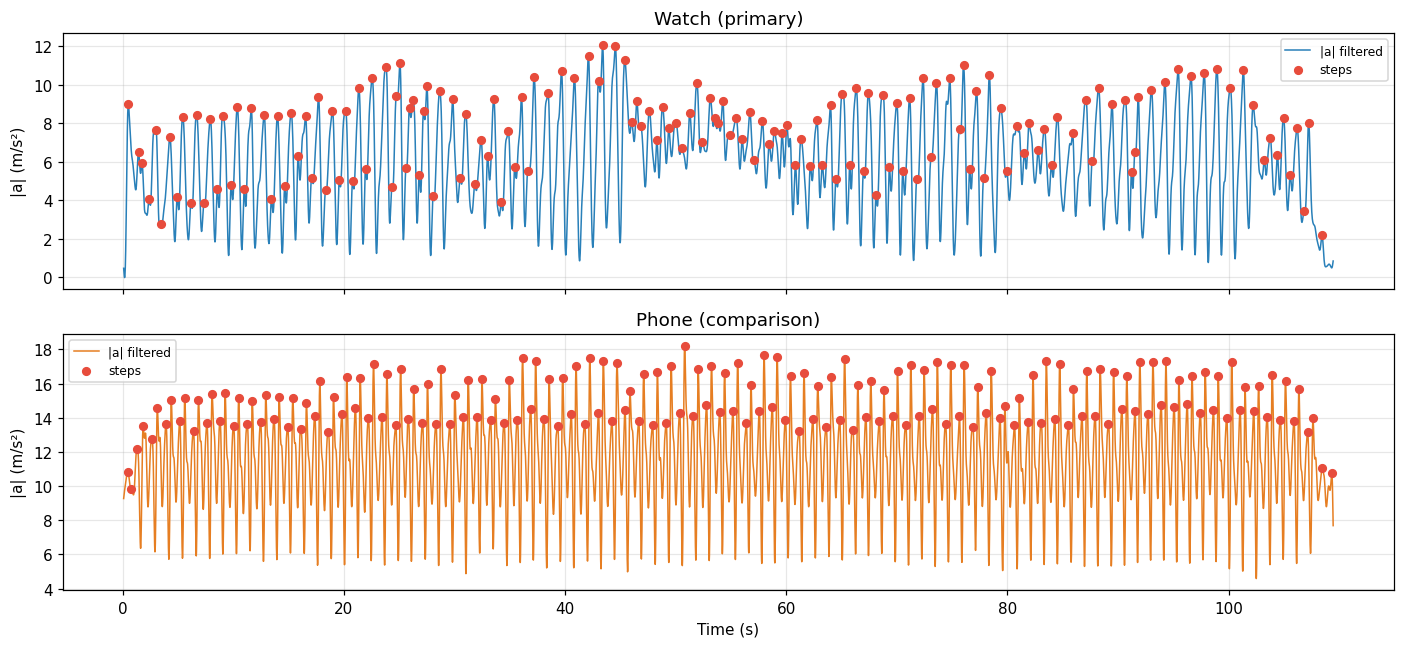

In [4]:
def detect_steps_from_array(xyz, t, fs, min_height=1.2, min_dist_s=0.30, weinberg_k=0.41):
    """Returns (step_times, step_lengths, peak_indices)."""
    mag = np.sqrt((xyz**2).sum(axis=1))
    b, a = butter(4, 3.0 / (fs/2), btype='low')
    mag_f = filtfilt(b, a, mag)
    min_dist = int(min_dist_s * fs)
    peaks, _ = find_peaks(mag_f, height=min_height, distance=min_dist)
    if len(peaks) < 2:
        return np.array([]), np.array([]), peaks
    # Weinberg step length per step: K * (max - min)^0.25 over a window
    lengths = []
    for i, pk in enumerate(peaks):
        lo = peaks[i-1] if i > 0 else max(0, pk - min_dist)
        hi = peaks[i+1] if i < len(peaks)-1 else min(len(mag_f)-1, pk + min_dist)
        window = mag_f[lo:hi+1]
        lengths.append(weinberg_k * (window.max() - window.min())**0.25)
    return t[peaks], np.array(lengths), peaks

# Watch steps (primary)
if w_accel_r is not None:
    w_xyz = w_accel_r[['x','y','z']].to_numpy()
    w_step_t, w_step_l, w_peaks = detect_steps_from_array(w_xyz, t_grid, FS,
                                    MIN_PEAK_HEIGHT, MIN_PEAK_DIST_S, WEINBERG_K)
    print(f'Watch : {len(w_step_t):3d} steps  |  '
          f'total distance {w_step_l.sum():.1f} m  |  '
          f'mean step {w_step_l.mean():.3f} m')
else:
    w_step_t, w_step_l, w_peaks = np.array([]), np.array([]), np.array([])
    print('Watch accel not available — using phone steps only.')

# Phone steps (comparison)
p_src = p_total_r if p_total_r is not None else p_accel_r
p_xyz = p_src[['x','y','z']].to_numpy()
p_step_t, p_step_l, p_peaks = detect_steps_from_array(p_xyz, t_grid, FS,
                                MIN_PEAK_HEIGHT, MIN_PEAK_DIST_S, WEINBERG_K)
print(f'Phone : {len(p_step_t):3d} steps  |  '
      f'total distance {p_step_l.sum():.1f} m  |  '
      f'mean step {p_step_l.mean():.3f} m')

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
for ax, xyz, peaks, label, col in [
        (axes[0], w_xyz if w_accel_r is not None else p_xyz, w_peaks, 'Watch (primary)', '#2980b9'),
        (axes[1], p_xyz, p_peaks, 'Phone (comparison)', '#e67e22')]:
    mag = np.sqrt((xyz**2).sum(axis=1))
    b, a = butter(4, 3.0/(FS/2), btype='low')
    mag_f = filtfilt(b, a, mag)
    ax.plot(t_grid, mag_f, color=col, linewidth=1, label='|a| filtered')
    ax.scatter(t_grid[peaks], mag_f[peaks], color='#e74c3c', s=25, zorder=5, label='steps')
    ax.set_ylabel('|a| (m/s²)')
    ax.set_title(label)
    ax.legend(fontsize=8)
axes[1].set_xlabel('Time (s)')
fig.tight_layout()
plt.show()


## 5. Heading from orientation quaternion

**Pipeline:**
1. Convert orientation quaternion → 3×3 rotation matrix R at every sample
2. Project phone forward axis through R into world frame: `world_fwd = R @ fwd_axis`
3. `heading = atan2(world_fwd_north, world_fwd_east)` — tilt-compensated, works in any pocket orientation
4. Auto-select the forward axis (±X/Y/Z) that gives closest to ±360° total turn for the loop
5. **Low-pass at 0.5 Hz** — removes step-frequency oscillations (~1.5 Hz) while preserving turns

**Remaining limitation:** the Android OS orientation filter uses the magnetometer for yaw.
Indoor metal (NU building steel frame, elevators) distorts the field, causing slow yaw drift.
This is what motivates the classical EKF baseline — gyro integration with explicit bias
estimation is not magnetometer-dependent between corrections.


Trying all 6 candidate forward axes:
  Axis        Total turn (deg)  Note
  -------------------------------------------------------
  +X                    -515.5°
  -X                    -515.5°
  +Y                   +3781.4°
  -Y                   +3781.4°
  +Z                    -517.8°
  -Z                    -517.8°

Best axis: +X  (total turn -515.5°, expect ±360° for a full loop)

If no axis gives close to ±360°, the quaternion convention may differ.
Check: does Orientation.csv have qw,qx,qy,qz columns or something else?
Columns found: ['qz', 'qy', 'qx', 'qw', 'roll', 'pitch', 'yaw']


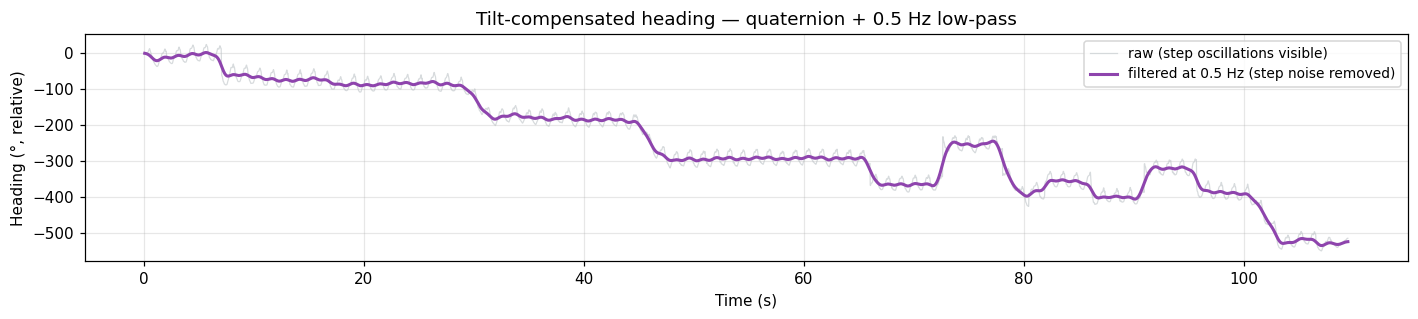

Total heading change: -525.0°
Expected for one clockwise loop: ~−360°
Residual drift: -165.0°  (indoor magnetic disturbance on OS orientation filter)

What to look for: 4 flat segments separated by ~90° drops.
Clockwise walk -> heading goes: 0 -> -90 -> -180 -> -270 -> -360


In [5]:
def quat_to_R(q):
    """
    Convert quaternion (N,4) [qw,qx,qy,qz] to rotation matrices (N,3,3).
    R transforms a vector from phone frame to world frame: v_world = R @ v_phone
    """
    qw, qx, qy, qz = q[:,0], q[:,1], q[:,2], q[:,3]
    N = len(q)
    R = np.zeros((N, 3, 3))
    R[:,0,0] = 1 - 2*(qy**2 + qz**2)
    R[:,0,1] = 2*(qx*qy - qw*qz)
    R[:,0,2] = 2*(qx*qz + qw*qy)
    R[:,1,0] = 2*(qx*qy + qw*qz)
    R[:,1,1] = 1 - 2*(qx**2 + qz**2)
    R[:,1,2] = 2*(qy*qz - qw*qx)
    R[:,2,0] = 2*(qx*qz - qw*qy)
    R[:,2,1] = 2*(qy*qz + qw*qx)
    R[:,2,2] = 1 - 2*(qx**2 + qy**2)
    return R


def heading_from_quaternion(p_orient, t_grid, forward_axis=np.array([0.,0.,-1.])):
    """
    Compute tilt-compensated heading at every sample in t_grid.

    Projects `forward_axis` (phone frame) into world XY using the rotation
    matrix derived from the orientation quaternion, then takes atan2.

    Parameters
    ----------
    p_orient     : Orientation.csv DataFrame (must have qw,qx,qy,qz columns)
    t_grid       : common time grid (seconds_elapsed)
    forward_axis : which phone-frame axis points forward (default -Z)

    Returns
    -------
    heading : (N,) unwrapped heading in radians, zeroed at start
    """
    q_cols = ['qw','qx','qy','qz']
    # Handle Sensor Logger column name variants
    col_map = {}
    for c in q_cols:
        if c not in p_orient.columns:
            alt = c[1:]  # 'qw'->'w' etc.
            if alt in p_orient.columns:
                col_map[alt] = c
    if col_map:
        p_orient = p_orient.rename(columns=col_map)

    t_ori = p_orient['seconds_elapsed'].to_numpy()
    q = np.stack([np.interp(t_grid, t_ori, p_orient[c].to_numpy())
                  for c in q_cols], axis=1)   # (N,4)
    q /= np.linalg.norm(q, axis=1, keepdims=True)

    R = quat_to_R(q)                           # (N,3,3)
    # world_fwd[i] = R[i] @ forward_axis
    world_fwd = np.einsum('nij,j->ni', R, forward_axis)  # (N,3)

    raw = np.arctan2(world_fwd[:,1], world_fwd[:,0])  # East=0, North=1
    unwrapped = np.unwrap(raw)
    unwrapped -= unwrapped[0]
    return unwrapped


# ── Diagnostic: try all 6 axes, find which gives ~±360° for the loop ─────────
h_dense = None

if p_orient is not None:
    print('Trying all 6 candidate forward axes:')
    print(f'  {"Axis":8s}  {"Total turn (deg)":>18s}  {"Note"}')
    print('  ' + '-'*55)
    candidates = {
        '+X': np.array([ 1., 0., 0.]),
        '-X': np.array([-1., 0., 0.]),
        '+Y': np.array([ 0., 1., 0.]),
        '-Y': np.array([ 0.,-1., 0.]),
        '+Z': np.array([ 0., 0., 1.]),
        '-Z': np.array([ 0., 0.,-1.]),
    }
    best_axis_name = None
    best_axis_vec  = None
    best_score     = np.inf
    for name, axis in candidates.items():
        h = heading_from_quaternion(p_orient, t_grid, forward_axis=axis)
        total_deg = np.degrees(h[-1])
        # Clockwise rectangle = -360, counter-clockwise = +360
        score = min(abs(total_deg - (-360)), abs(total_deg - 360))
        note = '  <-- BEST' if score < best_score else ''
        if score < best_score:
            best_score = score
            best_axis_name = name
            best_axis_vec  = axis
            # Clear previous best marker (reprint after loop)
        print(f'  {name:8s}  {total_deg:>+18.1f}°')

    print()
    print(f'Best axis: {best_axis_name}  (total turn {np.degrees(heading_from_quaternion(p_orient, t_grid, best_axis_vec)[-1]):+.1f}°, '
          f'expect ±360° for a full loop)')
    print()
    print('If no axis gives close to ±360°, the quaternion convention may differ.')
    print('Check: does Orientation.csv have qw,qx,qy,qz columns or something else?')
    print('Columns found:', [c for c in p_orient.columns if c not in ['time','seconds_elapsed']])

    # ── Use best axis for heading ─────────────────────────────────────────────
    h_dense = heading_from_quaternion(p_orient, t_grid, forward_axis=best_axis_vec)

    # ── Low-pass filter to remove step-frequency oscillations ───────────────
    # Steps occur at ~1.5 Hz; turns last ~1-2 s.
    # 0.5 Hz cutoff passes turns (>2 s) and removes step wobble (<0.67 s).
    from scipy.signal import butter, filtfilt
    b_lp, a_lp = butter(2, 0.5 / (FS / 2), btype='low')
    h_raw   = h_dense.copy()       # keep raw for plotting
    h_dense = filtfilt(b_lp, a_lp, h_dense)
    h_dense -= h_dense[0]          # re-zero after filter

    # ── Plot: raw vs filtered ─────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(13, 3))
    ax.plot(t_grid, np.degrees(h_raw),   color='#bdc3c7', linewidth=0.8,
            alpha=0.6, label='raw (step oscillations visible)')
    ax.plot(t_grid, np.degrees(h_dense), color='#8e44ad', linewidth=2,
            label='filtered at 0.5 Hz (step noise removed)')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Heading (°, relative)')
    ax.set_title('Tilt-compensated heading — quaternion + 0.5 Hz low-pass')
    ax.legend(fontsize=9)
    fig.tight_layout()
    plt.show()

    total_turn = np.degrees(h_dense[-1])
    print(f'Total heading change: {total_turn:+.1f}°')
    print(f'Expected for one clockwise loop: ~−360°')
    print(f'Residual drift: {total_turn + 360:+.1f}°  '
          f'(indoor magnetic disturbance on OS orientation filter)')
    print()
    print('What to look for: 4 flat segments separated by ~90° drops.')
    print('Clockwise walk -> heading goes: 0 -> -90 -> -180 -> -270 -> -360')
else:
    print('Orientation.csv not loaded — cannot compute heading.')


## 6. Trajectories

| Variant | Steps | Heading |
|---|---|---|
| Phone steps + quat heading | phone | quaternion + 0.5 Hz LP |
| **Watch steps + quat heading** | **watch** | same |
| Phone steps + OS yaw (baseline) | phone | raw `yaw` column |

With the filtered heading each straight segment should now be a clean line.
Remaining shape distortion comes from magnetometer drift (~155° over 110 s indoors).


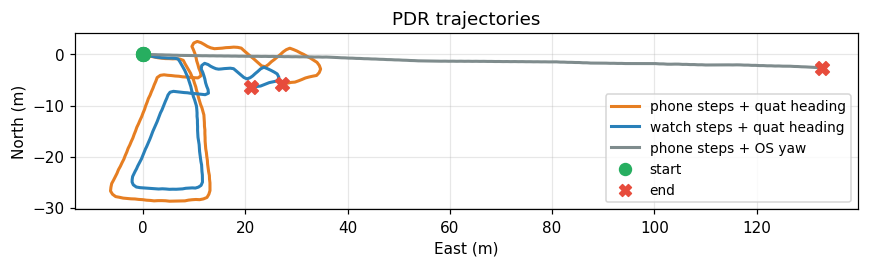

phone steps + quat heading           dist  133.0 m  closure error  27.8 m
watch steps + quat heading           dist  103.0 m  closure error  22.0 m
phone steps + OS yaw                 dist  133.0 m  closure error 132.9 m


In [6]:
def build_trajectory(step_times, step_lengths, heading_dense, t_dense):
    """Accumulate 2D position step by step using interpolated heading."""
    headings = np.interp(step_times, t_dense, heading_dense)
    xy = np.zeros((len(step_times) + 1, 2))
    for i, (h, l) in enumerate(zip(headings, step_lengths)):
        xy[i+1] = xy[i] + l * np.array([np.cos(h), np.sin(h)])
    return xy


trajectories = {}

if h_dense is not None:
    if len(p_step_t) > 0:
        trajectories['phone steps\n+ quat heading'] = build_trajectory(
            p_step_t, p_step_l, h_dense, t_grid)
    if len(w_step_t) > 0:
        trajectories['watch steps\n+ quat heading'] = build_trajectory(
            w_step_t, w_step_l, h_dense, t_grid)

# OS yaw baseline
if p_orient is not None and 'yaw' in p_orient.columns and len(p_step_t) > 0:
    os_yaw_raw = np.interp(t_grid,
                            p_orient['seconds_elapsed'].to_numpy(),
                            p_orient['yaw'].to_numpy())
    os_yaw = np.unwrap(np.radians(os_yaw_raw))
    os_yaw -= os_yaw[0]
    trajectories['phone steps\n+ OS yaw'] = build_trajectory(
        p_step_t, p_step_l, os_yaw, t_grid)

# ── Plot ──────────────────────────────────────────────────────────────────────
colors = ['#e67e22', '#2980b9', '#7f8c8d']
fig, ax = plt.subplots(figsize=(8, 8))
for (label, xy), col in zip(trajectories.items(), colors):
    ax.plot(xy[:,0], xy[:,1], color=col, linewidth=2,
            label=label.replace('\n', ' '))
    ax.scatter(xy[0,0],  xy[0,1],  color='#27ae60', s=80, zorder=5)
    ax.scatter(xy[-1,0], xy[-1,1], color='#e74c3c', s=80, marker='X', zorder=5)
ax.scatter([], [], color='#27ae60', s=60, label='start')
ax.scatter([], [], color='#e74c3c', s=60, marker='X', label='end')
ax.set_aspect('equal')
ax.set_xlabel('East (m)'); ax.set_ylabel('North (m)')
ax.set_title('PDR trajectories')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

for label, xy in trajectories.items():
    total = np.sum(np.linalg.norm(np.diff(xy, axis=0), axis=1))
    closure = np.linalg.norm(xy[-1])
    print(f"{label.replace(chr(10),' '):35s}  "
          f"dist {total:6.1f} m  closure error {closure:5.1f} m")


## 7. GPS reference vs best PDR estimate

Both in the same local East/North frame (origin = first GPS fix).
GPS dots are sized by `horizontalAccuracy` — larger dot = less accurate fix.


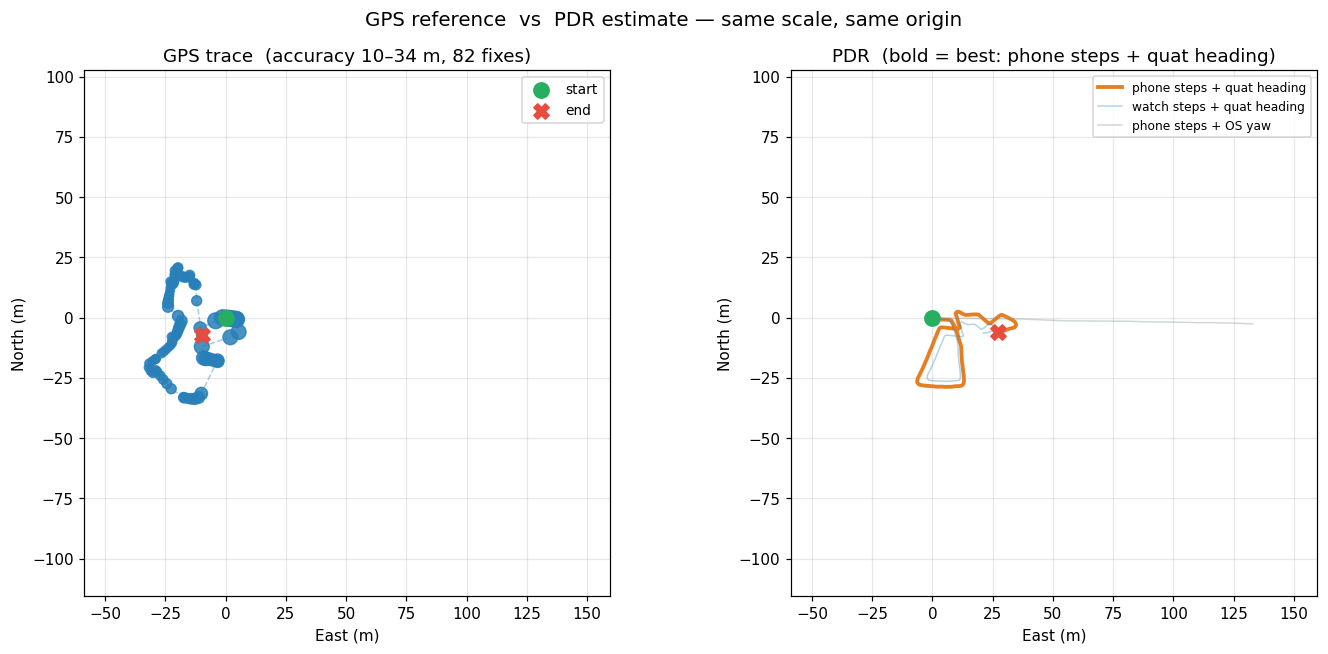

In [7]:
def latlon_to_en(lat, lon, lat0, lon0):
    R = 6_371_000.0
    north = np.radians(lat - lat0) * R
    east  = np.radians(lon - lon0) * R * np.cos(np.radians(lat0))
    return east, north

has_gps = p_loc is not None and not p_loc.empty and {'latitude','longitude'}.issubset(p_loc.columns)
best_key = 'watch steps\n+ accel heading' if 'watch steps\n+ accel heading' in trajectories \
           else (list(trajectories.keys())[0] if trajectories else None)

if has_gps and best_key:
    lat0, lon0 = p_loc['latitude'].iloc[0], p_loc['longitude'].iloc[0]
    gps_e, gps_n = latlon_to_en(p_loc['latitude'].to_numpy(),
                                  p_loc['longitude'].to_numpy(), lat0, lon0)
    acc = p_loc['horizontalAccuracy'].to_numpy() if 'horizontalAccuracy' in p_loc.columns else None

    xy_best = trajectories[best_key]

    fig, axes = plt.subplots(1, 2, figsize=(13, 6))

    # ── Left: GPS ─────────────────────────────────────────────────────────────
    ax = axes[0]
    ax.plot(gps_e, gps_n, color='#2980b9', linewidth=1, linestyle='--', alpha=0.4)
    dot_size = (acc / acc.min() * 30) if acc is not None else 40
    ax.scatter(gps_e, gps_n, c='#2980b9', s=dot_size, alpha=0.85, zorder=4)
    ax.scatter(gps_e[0],  gps_n[0],  color='#27ae60', s=100, zorder=6, label='start')
    ax.scatter(gps_e[-1], gps_n[-1], color='#e74c3c', s=100, marker='X', zorder=6, label='end')
    title = 'GPS trace'
    if acc is not None:
        title += f'  (accuracy {acc.min():.0f}–{acc.max():.0f} m, {len(p_loc)} fixes)'
    ax.set_title(title); ax.set_xlabel('East (m)'); ax.set_ylabel('North (m)')
    ax.set_aspect('equal'); ax.legend(fontsize=9)

    # ── Right: best PDR ────────────────────────────────────────────────────────
    ax2 = axes[1]
    # Also draw all trajectories faintly for context
    for (lbl, xy), col in zip(trajectories.items(), colors):
        lw = 2.5 if lbl == best_key else 1
        alpha = 1.0 if lbl == best_key else 0.35
        ax2.plot(xy[:,0], xy[:,1], color=col, linewidth=lw, alpha=alpha,
                 label=lbl.replace('\n',' '))
    ax2.scatter(0, 0, color='#27ae60', s=100, zorder=6)
    ax2.scatter(xy_best[-1,0], xy_best[-1,1], color='#e74c3c', s=100, marker='X', zorder=6)
    ax2.set_title(f'PDR  (bold = best: {best_key.replace(chr(10)," ")})')
    ax2.set_xlabel('East (m)'); ax2.set_ylabel('North (m)')
    ax2.set_aspect('equal'); ax2.legend(fontsize=8)

    # Shared axis limits
    all_x = np.concatenate([gps_e] + [r[:,0] for r in trajectories.values()])
    all_y = np.concatenate([gps_n] + [r[:,1] for r in trajectories.values()])
    span = max(all_x.max()-all_x.min(), all_y.max()-all_y.min())
    cx, cy = (all_x.max()+all_x.min())/2, (all_y.max()+all_y.min())/2
    half = span/2 + span*0.15 + 2
    for ax in axes:
        ax.set_xlim(cx-half, cx+half)
        ax.set_ylim(cy-half, cy+half)

    fig.suptitle('GPS reference  vs  PDR estimate — same scale, same origin', fontsize=13)
    fig.tight_layout()
    plt.show()
else:
    print('GPS data or trajectories missing — skipping comparison.')
